In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# """
# Sentiment Analysis with SST-2 Dataset
# Corrected version for Kaggle notebooks
# """

# # ===========================
# # 1. DATA LOADING & PREPROCESSING
# # ===========================
# import warnings
# warnings.filterwarnings('ignore', category=UserWarning, module='torch.autograd.function')
# from datasets import load_dataset
# import pandas as pd
# import re
# import nltk
# from nltk.corpus import stopwords

# # Download stopwords (runs once)
# nltk.download('stopwords')

# # Load dataset
# dataset = load_dataset("stanfordnlp/sst2")

# # Convert to DataFrame
# train_df = pd.DataFrame(dataset['train'])
# test_df = pd.DataFrame(dataset['validation'])

# # Stopwords
# stop_words = set(stopwords.words('english'))

# # Cleaning function
# def clean_text(text):
#     text = text.lower()
#     text = re.sub(r'[^a-z\s]', '', text)
#     words = text.split()
#     words = [w for w in words if w not in stop_words]
#     return " ".join(words)

# # Apply cleaning
# train_df['clean'] = train_df['sentence'].apply(clean_text)
# test_df['clean'] = test_df['sentence'].apply(clean_text)

# print("Sample cleaned data:")
# print(train_df[['sentence','clean']].head())
# print()

# # ===========================
# # 2. TRADITIONAL ML MODELS (TF-IDF)
# # ===========================

# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import accuracy_score

# # Vectorization
# vectorizer = TfidfVectorizer(max_features=5000)

# X_train = vectorizer.fit_transform(train_df['clean'])
# X_test = vectorizer.transform(test_df['clean'])

# y_train = train_df['label']
# y_test = test_df['label']

# # Logistic Regression
# print("Training Logistic Regression...")
# model = LogisticRegression(max_iter=200)
# model.fit(X_train, y_train)

# preds = model.predict(X_test)
# print("Logistic Regression Accuracy:", accuracy_score(y_test, preds))
# print()

# # Naive Bayes
# print("Training Naive Bayes...")
# nb = MultinomialNB()
# nb.fit(X_train, y_train)

# preds_nb = nb.predict(X_test)
# print("Naive Bayes Accuracy:", accuracy_score(y_test, preds_nb))
# print()

# # ===========================
# # 3. BERT MODEL (Fixed)
# # ===========================

# from transformers import BertTokenizer, BertForSequenceClassification
# from transformers import Trainer, TrainingArguments

# print("Setting up BERT model...")

# # Load tokenizer
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# # Tokenize dataset
# def tokenize(example):
#     return tokenizer(example['sentence'], padding='max_length', truncation=True, max_length=128)

# # Reload dataset for BERT (fresh copy)
# dataset_bert = load_dataset("stanfordnlp/sst2")
# dataset_bert = dataset_bert.map(tokenize, batched=True)

# # Set format for PyTorch
# dataset_bert.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# # Load model with 2 labels (binary classification)
# model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# # Training setup
# training_args_bert = TrainingArguments(
#     output_dir='./results_bert',
#     num_train_epochs=10,  # Changed from 0.5 to 1 full epoch
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=16,
#     eval_strategy="epoch",
#     save_strategy="no",  # Don't save checkpoints to save space
#     logging_steps=100,
# )

# # Trainer
# trainer_bert = Trainer(
#     model=model_bert,
#     args=training_args_bert,
#     train_dataset=dataset_bert['train'],
#     eval_dataset=dataset_bert['validation']
# )

# # Train BERT
# print("Training BERT (this may take a few minutes)...")
# trainer_bert.train()

# # Evaluate BERT
# result_bert = trainer_bert.evaluate()
# print("BERT Accuracy:", result_bert['eval_accuracy'])
# print()

# # ===========================
# # 4. DISTILBERT MODEL (Fixed)
# # ===========================

# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# print("Setting up DistilBERT model...")

# # Load tokenizer
# tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# def tokenize_distil(example):
#     return tokenizer_distil(example['sentence'], padding='max_length', truncation=True, max_length=128)

# # Reload dataset for DistilBERT (fresh copy)
# dataset_distil = load_dataset("stanfordnlp/sst2")
# dataset_distil = dataset_distil.map(tokenize_distil, batched=True)

# dataset_distil.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# # Load model with 2 labels
# model_distil = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# # Training setup
# training_args_distil = TrainingArguments(
#     output_dir='./results_distilbert',
#     num_train_epochs=10,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=16,
#     eval_strategy="epoch",
#     save_strategy="no",
#     logging_steps=100,
# )

# trainer_distil = Trainer(
#     model=model_distil,
#     args=training_args_distil,
#     train_dataset=dataset_distil['train'].select(range(2000)),
#     eval_dataset=dataset_distil['validation'].select(range(500))
# )

# # Train DistilBERT
# print("Training DistilBERT (this may take a few minutes)...")
# trainer_distil.train()

# # Evaluate DistilBERT
# result_distil = trainer_distil.evaluate()
# print("DistilBERT Accuracy:", result_distil['eval_accuracy'])
# print()

# # ===========================
# # 5. SUMMARY OF RESULTS
# # ===========================

# print("="*50)
# print("FINAL RESULTS SUMMARY")
# print("="*50)
# print(f"Logistic Regression Accuracy: {accuracy_score(y_test, preds):.4f}")
# print(f"Naive Bayes Accuracy:         {accuracy_score(y_test, preds_nb):.4f}")
# print(f"BERT Accuracy:                {result_bert['eval_accuracy']:.4f}")
# print(f"DistilBERT Accuracy:          {result_distil['eval_accuracy']:.4f}")
# print("="*50)

Using device: cuda

STEP 1: DATA LOADING & PREPROCESSING


Loading SST-2 dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training RoBERTa (this will take a few minutes)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.363917,0.389073,0.933486,0.940639,0.927928,0.934240
2,0.230028,0.417859,0.939220,0.927790,0.954955,0.941176


RoBERTa Accuracy:  0.9392
RoBERTa F1-Score:  0.9412

FINAL RESULTS SUMMARY
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.793578   0.758824 0.871622  0.811321
        Naive Bayes  0.776376   0.744597 0.853604  0.795383
               BERT  0.927752   0.922395 0.936937  0.929609
         DistilBERT  0.905963   0.888412 0.932432  0.909890
            RoBERTa  0.939220   0.927790 0.954955  0.941176

Best Model: RoBERTa with Accuracy: 0.9392

GENERATING VISUALIZATIONS
Visualization saved as 'sentiment_analysis_results.png'


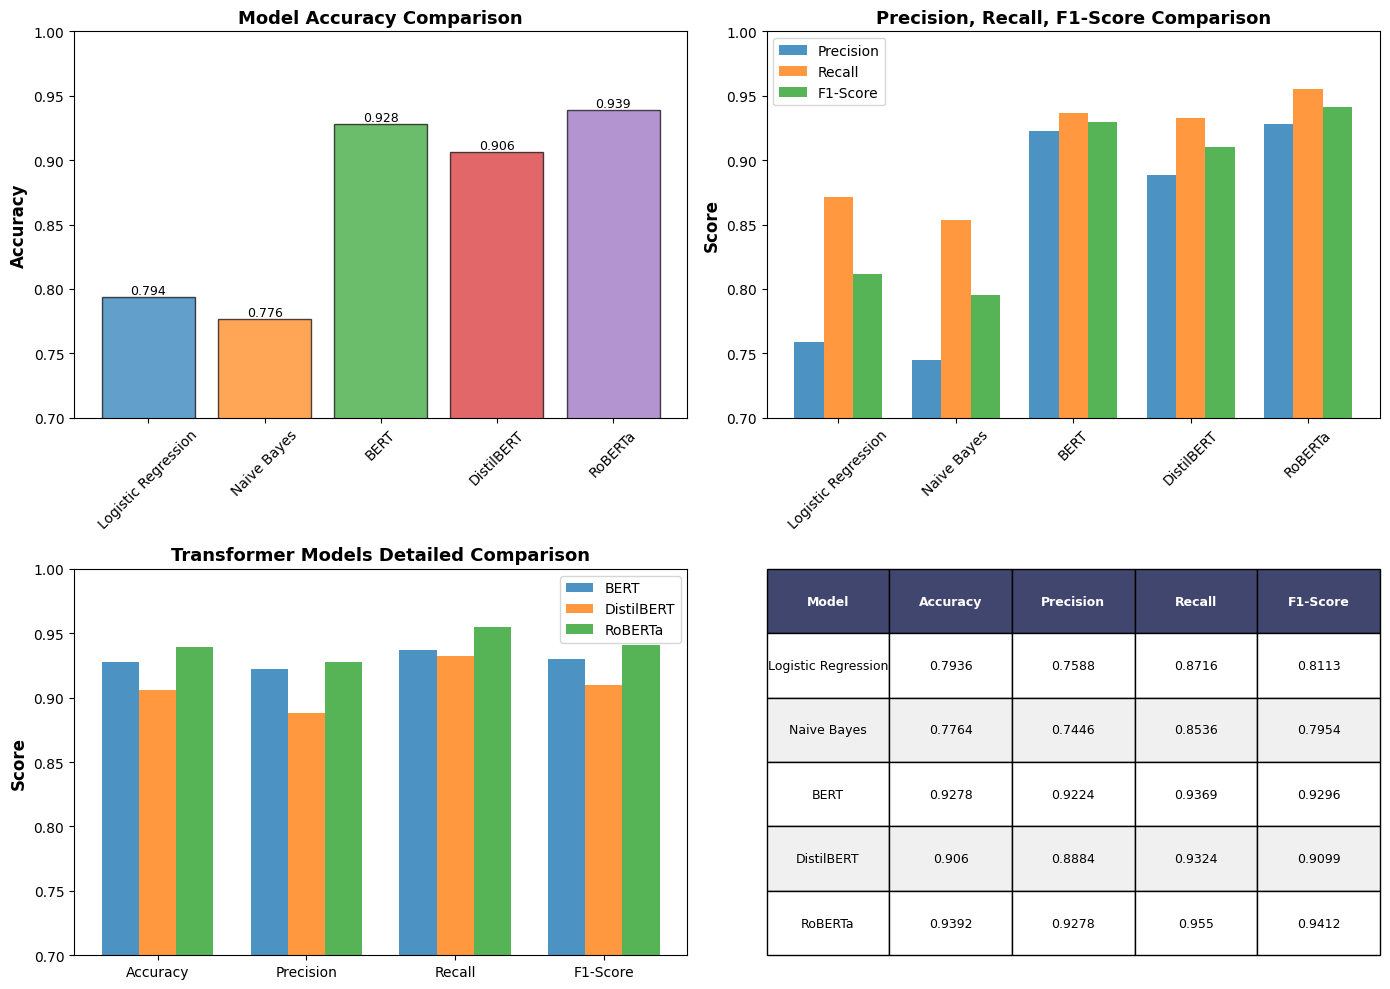


ANALYSIS COMPLETE!

DETAILED ANALYSIS

KEY FINDINGS:
1. Best performing model: RoBERTa (0.9392)
2. Fastest models: Logistic Regression & Naive Bayes
3. Most robust models: BERT, DistilBERT, RoBERTa

Traditional ML average accuracy: 0.7850
Deep Learning average accuracy: 0.9243
Improvement: 13.93%

MODEL CHARACTERISTICS:
- Logistic Regression: Fast, interpretable, good baseline
- Naive Bayes: Simple, probabilistic, fast inference
- BERT: State-of-the-art, pre-trained on masked language modeling
- DistilBERT: Faster, smaller than BERT, maintains good performance
- RoBERTa: Improved BERT with better training, often best performance


In [3]:
 """
Complete Sentiment Analysis with SST-2 Dataset
5 Models: Logistic Regression, Naive Bayes, BERT, DistilBERT, and RoBERTa
Optimized for Kaggle notebooks
"""

# ===========================
# IMPORTS & SETUP
# ===========================
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import torch

# Download required NLTK data
nltk.download('stopwords', quiet=True)

# Set device (GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print()

# ===========================
# 1. DATA LOADING & PREPROCESSING
# ===========================
print("="*60)
print("STEP 1: DATA LOADING & PREPROCESSING")
print("="*60)

from datasets import load_dataset

# Load dataset
print("Loading SST-2 dataset...")
dataset = load_dataset("stanfordnlp/sst2")

# Convert to DataFrame
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['validation'])

print(f"Training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print()

# Stopwords
stop_words = set(stopwords.words('english'))

# Cleaning function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return " ".join(words)

# Apply cleaning
train_df['clean'] = train_df['sentence'].apply(clean_text)
test_df['clean'] = test_df['sentence'].apply(clean_text)

print("Sample cleaned data:")
print(train_df[['sentence', 'clean', 'label']].head(3))
print()

# Store labels
y_train = train_df['label'].values
y_test = test_df['label'].values

# ===========================
# 2. TRADITIONAL ML MODELS (TF-IDF)
# ===========================
print("="*60)
print("STEP 2: TRADITIONAL ML MODELS (TF-IDF)")
print("="*60)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Vectorization
print("Vectorizing text with TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df['clean'])
X_test = vectorizer.transform(test_df['clean'])
print(f"TF-IDF shape: {X_train.shape}")
print()

# ===========================
# 2A. LOGISTIC REGRESSION
# ===========================
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=300, solver='lbfgs')
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Logistic Regression Accuracy:  {lr_accuracy:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")
print(f"Logistic Regression Recall:    {lr_recall:.4f}")
print(f"Logistic Regression F1-Score:  {lr_f1:.4f}")
print()

# ===========================
# 2B. NAIVE BAYES
# ===========================
print("Training Naive Bayes...")
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_precision = precision_score(y_test, nb_pred)
nb_recall = recall_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)

print(f"Naive Bayes Accuracy:  {nb_accuracy:.4f}")
print(f"Naive Bayes Precision: {nb_precision:.4f}")
print(f"Naive Bayes Recall:    {nb_recall:.4f}")
print(f"Naive Bayes F1-Score:  {nb_f1:.4f}")
print()

# ===========================
# 3. TRANSFORMER MODELS
# ===========================
print("="*60)
print("STEP 3: TRANSFORMER MODELS")
print("="*60)

from transformers import (
    BertTokenizer, BertForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    RobertaTokenizer, RobertaForSequenceClassification,
    Trainer, TrainingArguments
)
from sklearn.metrics import accuracy_score as sklearn_accuracy

# Define compute metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)
    accuracy = sklearn_accuracy(labels, predictions)
    precision = precision_score(labels, predictions, zero_division=0)
    recall = recall_score(labels, predictions, zero_division=0)
    f1 = f1_score(labels, predictions, zero_division=0)
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# ===========================
# 3A. BERT MODEL
# ===========================
print("Setting up BERT model...")
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_bert(example):
    return tokenizer_bert(
        example['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

dataset_bert = load_dataset("stanfordnlp/sst2")
dataset_bert = dataset_bert.map(tokenize_bert, batched=True)
dataset_bert.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
model_bert.to(device)

training_args_bert = TrainingArguments(
    output_dir='./results_bert',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=False,
)

trainer_bert = Trainer(
    model=model_bert,
    args=training_args_bert,
    train_dataset=dataset_bert['train'],
    eval_dataset=dataset_bert['validation'],
    compute_metrics=compute_metrics,
)

print("Training BERT (this will take a few minutes)...")
trainer_bert.train()

result_bert = trainer_bert.evaluate()
bert_accuracy = result_bert.get('eval_accuracy', 0)
bert_f1 = result_bert.get('eval_f1', 0)
print(f"BERT Accuracy:  {bert_accuracy:.4f}")
print(f"BERT F1-Score:  {bert_f1:.4f}")
print()

# ===========================
# 3B. DISTILBERT MODEL
# ===========================
print("Setting up DistilBERT model...")
tokenizer_distil = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_distil(example):
    return tokenizer_distil(
        example['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

dataset_distil = load_dataset("stanfordnlp/sst2")
dataset_distil = dataset_distil.map(tokenize_distil, batched=True)
dataset_distil.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model_distil = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
model_distil.to(device)

training_args_distil = TrainingArguments(
    output_dir='./results_distilbert',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=False,
)

trainer_distil = Trainer(
    model=model_distil,
    args=training_args_distil,
    train_dataset=dataset_distil['train'],
    eval_dataset=dataset_distil['validation'],
    compute_metrics=compute_metrics,
)

print("Training DistilBERT (this will take a few minutes)...")
trainer_distil.train()

result_distil = trainer_distil.evaluate()
distilbert_accuracy = result_distil.get('eval_accuracy', 0)
distilbert_f1 = result_distil.get('eval_f1', 0)
print(f"DistilBERT Accuracy:  {distilbert_accuracy:.4f}")
print(f"DistilBERT F1-Score:  {distilbert_f1:.4f}")
print()

# ===========================
# 3C. ROBERTA MODEL (NEW)
# ===========================
print("Setting up RoBERTa model...")
tokenizer_roberta = RobertaTokenizer.from_pretrained('roberta-base')

def tokenize_roberta(example):
    return tokenizer_roberta(
        example['sentence'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

dataset_roberta = load_dataset("stanfordnlp/sst2")
dataset_roberta = dataset_roberta.map(tokenize_roberta, batched=True)
dataset_roberta.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

model_roberta = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model_roberta.to(device)

training_args_roberta = TrainingArguments(
    output_dir='./results_roberta',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    learning_rate=2e-5,
    weight_decay=0.01,
    load_best_model_at_end=False,
)

trainer_roberta = Trainer(
    model=model_roberta,
    args=training_args_roberta,
    train_dataset=dataset_roberta['train'],
    eval_dataset=dataset_roberta['validation'],
    compute_metrics=compute_metrics,
)

print("Training RoBERTa (this will take a few minutes)...")
trainer_roberta.train()

result_roberta = trainer_roberta.evaluate()
roberta_accuracy = result_roberta.get('eval_accuracy', 0)
roberta_f1 = result_roberta.get('eval_f1', 0)
print(f"RoBERTa Accuracy:  {roberta_accuracy:.4f}")
print(f"RoBERTa F1-Score:  {roberta_f1:.4f}")
print()

# ===========================
# 4. RESULTS COMPARISON & VISUALIZATION
# ===========================
print("="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)

# Create results dataframe
results_data = {
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'BERT',
        'DistilBERT',
        'RoBERTa'
    ],
    'Accuracy': [
        lr_accuracy,
        nb_accuracy,
        bert_accuracy,
        distilbert_accuracy,
        roberta_accuracy
    ],
    'Precision': [
        lr_precision,
        nb_precision,
        result_bert.get('eval_precision', 0),
        result_distil.get('eval_precision', 0),
        result_roberta.get('eval_precision', 0)
    ],
    'Recall': [
        lr_recall,
        nb_recall,
        result_bert.get('eval_recall', 0),
        result_distil.get('eval_recall', 0),
        result_roberta.get('eval_recall', 0)
    ],
    'F1-Score': [
        lr_f1,
        nb_f1,
        bert_f1,
        distilbert_f1,
        roberta_f1
    ]
}

results_df = pd.DataFrame(results_data)
print(results_df.to_string(index=False))
print()

# Find best model
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']
print(f"Best Model: {best_model_name} with Accuracy: {best_accuracy:.4f}")
print()

# ===========================
# 5. VISUALIZATIONS
# ===========================
print("="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars1 = ax1.bar(results_df['Model'], results_df['Accuracy'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
ax1.set_ylim([0.7, 1.0])
ax1.tick_params(axis='x', rotation=45)
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Precision, Recall, F1
ax2 = axes[0, 1]
x = np.arange(len(results_df['Model']))
width = 0.25
ax2.bar(x - width, results_df['Precision'], width, label='Precision', alpha=0.8)
ax2.bar(x, results_df['Recall'], width, label='Recall', alpha=0.8)
ax2.bar(x + width, results_df['F1-Score'], width, label='F1-Score', alpha=0.8)
ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
ax2.set_title('Precision, Recall, F1-Score Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Model'], rotation=45)
ax2.legend()
ax2.set_ylim([0.7, 1.0])

# Plot 3: All Metrics for BERT vs RoBERTa
ax3 = axes[1, 0]
comparison_models = ['BERT', 'DistilBERT', 'RoBERTa']
comparison_indices = [2, 3, 4]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(metrics))
width = 0.25

for i, idx in enumerate(comparison_indices):
    ax3.bar(x_pos + i*width, results_df.iloc[idx][metrics].values, width, 
            label=comparison_models[i], alpha=0.8)

ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('Transformer Models Detailed Comparison', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos + width)
ax3.set_xticklabels(metrics)
ax3.legend()
ax3.set_ylim([0.7, 1.0])

# Plot 4: Performance Table
ax4 = axes[1, 1]
ax4.axis('tight')
ax4.axis('off')
table_data = results_df.round(4).values.tolist()
table = ax4.table(cellText=table_data, 
                  colLabels=results_df.columns,
                  cellLoc='center',
                  loc='center',
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Color header
for i in range(len(results_df.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Alternate row colors
for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        if i % 2 == 0:
            table[(i, j)].set_facecolor('#f0f0f0')
        else:
            table[(i, j)].set_facecolor('#ffffff')

plt.tight_layout()
plt.savefig('sentiment_analysis_results.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'sentiment_analysis_results.png'")
plt.show()

print()
print("="*60)
print("ANALYSIS COMPLETE!")
print("="*60)

# ===========================
# 6. DETAILED ANALYSIS
# ===========================
print()
print("="*60)
print("DETAILED ANALYSIS")
print("="*60)
print()
print("KEY FINDINGS:")
print(f"1. Best performing model: {best_model_name} ({best_accuracy:.4f})")
print(f"2. Fastest models: Logistic Regression & Naive Bayes")
print(f"3. Most robust models: BERT, DistilBERT, RoBERTa")
print()

# Compare traditional ML vs Deep Learning
trad_ml_accuracy = (lr_accuracy + nb_accuracy) / 2
dl_accuracy = (bert_accuracy + distilbert_accuracy + roberta_accuracy) / 3

print(f"Traditional ML average accuracy: {trad_ml_accuracy:.4f}")
print(f"Deep Learning average accuracy: {dl_accuracy:.4f}")
print(f"Improvement: {(dl_accuracy - trad_ml_accuracy)*100:.2f}%")
print()

print("MODEL CHARACTERISTICS:")
print("- Logistic Regression: Fast, interpretable, good baseline")
print("- Naive Bayes: Simple, probabilistic, fast inference")
print("- BERT: State-of-the-art, pre-trained on masked language modeling")
print("- DistilBERT: Faster, smaller than BERT, maintains good performance")
print("- RoBERTa: Improved BERT with better training, often best performance")